In [2]:
from pyspark.sql import SparkSession
# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("Project 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '4g')
    .getOrCreate()
)

your 131072x1 screen size is bogus. expect trouble
24/08/24 20:21:28 WARN Utils: Your hostname, LAPTOP-MVJAK2N9 resolves to a loopback address: 127.0.1.1; using 172.18.112.204 instead (on interface eth0)
24/08/24 20:21:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/08/24 20:21:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## download datasets


In [1]:
import os

base_dir= '../../project-1-individual-WYJ-unimelb/'
data_folder = [
    'data/raw/yellow_taxi',
    'data/raw/fhvhv'
]

for i in data_folder:
    path = os.path.join(base_dir,i)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f'create folder:{path}')

In [2]:
import os
import requests
from bs4 import BeautifulSoup

folder_address = "../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/"

# NYC Taxi Data website link
url = "https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page"

# get the detail for website
response = requests.get(url)
html_content = response.text

# use beautiful to analysis the website
soup = BeautifulSoup(html_content, 'html.parser')

# find all the link for yellow taxi in 2023
links = soup.find_all('a', href=True)
yellow_taxi_links = []

# Filtering links containing ‘yellow_tripdata_2023’
for link in links:
    href = link['href']
    if 'yellow_tripdata_2023' in href:
        full_link = href if href.startswith('http') else 'https://www.nyc.gov' + href
        yellow_taxi_links.append(full_link)

#put the data into the folder yellow taxi
for link in yellow_taxi_links:
    link = link.strip()
    
    filename = os.path.join(folder_address, link.split('/')[-1])
    print(f"Downloading {filename}...")
    
    with requests.get(link, stream=True) as r:
        r.raise_for_status()
        with open(filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"{filename} downloaded successfully!")


../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-01.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-02.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-03.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-04.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-05.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-06.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-07.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-08.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yell

In [8]:
import os
import requests
from bs4 import BeautifulSoup


folder_address = "../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/"

url = "https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page"

response = requests.get(url)
html_content = response.text

soup = BeautifulSoup(html_content, 'html.parser')

links = soup.find_all('a', href=True)
fhvhv_links = []

for link in links:
    href = link['href']
    if 'fhvhv_tripdata_2023' in href:
        full_link = href if href.startswith('http') else 'https://www.nyc.gov' + href
        fhvhv_links.append(full_link)

for link in fhvhv_links:
    link = link.strip()
    filename = os.path.join(folder_address, link.split('/')[-1])
    print(f"Downloading {filename}...")   
    with requests.get(link, stream=True) as r:
        r.raise_for_status()  
        with open(filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    
    print(f"{filename} downloaded successfully!")


../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-01.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-02.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-03.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-04.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-05.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-06.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-07.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-08.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fhvhv/fhvhv_tripdata_2023-09.parquet downloaded successfully!
../../project-1-individual-WYJ-unimelb/data/fh

## Preprocessing 

In [4]:
yellow1 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-01.parquet')
#yellow2 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-02.parquet')
yellow3 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-03.parquet')
yellow4 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-04.parquet')
#yellow5 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-05.parquet')
yellow6 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-06.parquet')
yellow7 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-07.parquet')
#yellow8 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-08.parquet')
yellow9 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-09.parquet')
yellow10 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-10.parquet')
#yellow11 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-11.parquet')
yellow12 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/yellow_taxi/yellow_tripdata_2023-12.parquet')

In [5]:
from pyspark.sql import functions as F
yellow = yellow1.union(yellow3).union(yellow4).union(yellow6).union(yellow7).union(yellow9).union(yellow10).union(yellow12)
yellow_with_month = yellow.withColumn('month', F.month(yellow['tpep_pickup_datetime']))
yellow_with_month = yellow_with_month.withColumnRenamed("tpep_pickup_datetime", "pickup_time")
yellow_with_month = yellow_with_month.withColumnRenamed("tpep_dropoff_datetime", "dropoff_time")
yellow_with_month = yellow_with_month.withColumn('pickup_time', F.to_timestamp('pickup_time'))
yellow_with_month = yellow_with_month.withColumn('dropoff_time', F.to_timestamp('dropoff_time'))
yellow_with_month = yellow_with_month.withColumn('time_spend', F.col('dropoff_time').cast('long') - F.col('pickup_time').cast('long'))
yellow_with_month = yellow_with_month.withColumn('time_spend', F.round(F.col('time_spend') / 60, 3))
yellow_with_month = yellow_with_month.withColumn('taxi_type', F.lit('Yellow'))


In [6]:
yellow_with_month.count()

25718698

In [7]:
required_col = ('pickup_time','dropoff_time','trip_distance','tip_amount','fare_amount','total_amount','time_spend','taxi_type')
yellow_taxi = yellow_with_month.select(*required_col)


In [8]:
fhvhv1 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-01.parquet')
#fhvhv2 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-02.parquet')
fhvhv3 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-03.parquet')
fhvhv4 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-04.parquet')
#fhvhv5 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-05.parquet')
fhvhv6 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-06.parquet')
fhvhv7 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-07.parquet')
#fhvhv8 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-08.parquet')
fhvhv9 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-09.parquet')
fhvhv10 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-10.parquet')
#fhvhv11 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-11.parquet')
fhvhv12 = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/raw/fhvhv/fhvhv_tripdata_2023-12.parquet')

In [9]:
from pyspark.sql import functions as F
fhvhv = fhvhv1.union(fhvhv3).union(fhvhv4).union(fhvhv6).union(fhvhv7).union(fhvhv9).union(fhvhv10).union(fhvhv12)
fhvhv_with_month = fhvhv.withColumn('month', F.month(fhvhv['pickup_datetime']))
fhvhv_with_month = fhvhv_with_month.withColumnRenamed('pickup_datetime', 'pickup_time')
fhvhv_with_month = fhvhv_with_month.withColumnRenamed('dropoff_datetime', 'dropoff_time')
fhvhv_with_month = fhvhv_with_month.withColumn('time_spend', F.round(F.col('trip_time') / 60, 3))
fhvhv_with_month = fhvhv_with_month.withColumnRenamed('trip_miles','trip_distance')
fhvhv_with_month = fhvhv_with_month.withColumnRenamed('base_passenger_fare','fare_amount')
fhvhv_with_month = fhvhv_with_month.withColumnRenamed('tips','tip_amount')
fhvhv_with_month = fhvhv_with_month.withColumn('taxi_type', F.lit('fhvhv'))
fhvhv_with_month = fhvhv_with_month.withColumnRenamed('driver_pay','total_amount')


In [10]:
required_col = ('pickup_time','dropoff_time','trip_distance','tip_amount','fare_amount','total_amount','time_spend','taxi_type')
fhvhv_taxi = fhvhv_with_month.select(*required_col)


In [11]:
fhvhv_with_month.count()

157089973

In [12]:
taxi = yellow_taxi.union(fhvhv_taxi)
taxi.count()

182808671

In [13]:
taxi = yellow_taxi.union(fhvhv_taxi)
taxi = taxi.filter(F.col('time_spend') >= 0)
taxi = taxi.filter(F.col('fare_amount') >= 0)
taxi = taxi.filter(F.col('total_amount') >= 0)
taxi = taxi.filter(F.col('tip_amount') >= 0)
taxi = taxi.filter(F.col('trip_distance') >= 0.5)
taxi = taxi.withColumn('pickup_date', F.to_date('pickup_time'))
required_col = ('pickup_date','trip_distance','tip_amount','fare_amount','total_amount','time_spend','taxi_type')
taxi = taxi.select(*required_col)


In [14]:
#remove fare amout outlier
Q1 = taxi.approxQuantile('fare_amount', [0.25], 0.1)[0]
Q3 = taxi.approxQuantile('fare_amount', [0.75], 0.1)[0]
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
taxi = taxi.filter(F.col('fare_amount') >= lower)
taxi = taxi.filter(F.col('fare_amount')<= upper)


In [15]:
#remove time spend outlier 
Q1 = taxi.approxQuantile('time_spend', [0.25], 0.1)[0]
Q3 = taxi.approxQuantile('time_spend', [0.75], 0.1)[0]
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
taxi = taxi.filter(F.col('time_spend') >= lower)
taxi = taxi.filter(F.col('time_spend')<= upper)



In [16]:
taxi.count()

160209021

In [17]:
taxi = taxi.filter(F.col("pickup_date").like("2023%"))
taxi = taxi.groupBy('pickup_date', 'taxi_type') \
    .agg(F.round(F.sum("tip_amount"),4).alias("total_tip_each_taxi"),
         F.count("*").alias('taxi_type_count')
         )

taxi.show()

+-----------+---------+-------------------+---------------+
|pickup_date|taxi_type|total_tip_each_taxi|taxi_type_count|
+-----------+---------+-------------------+---------------+
| 2023-01-02|   Yellow|          151580.83|          54282|
| 2023-01-13|   Yellow|          298095.55|          96889|
| 2023-01-16|   Yellow|          207511.15|          68972|
| 2023-01-27|   Yellow|          300658.26|          99210|
| 2023-01-31|   Yellow|          267549.22|          88175|
| 2023-01-19|   Yellow|          311898.08|         101197|
| 2023-01-30|   Yellow|          218270.23|          72917|
| 2023-01-21|   Yellow|          287537.01|         101224|
| 2023-01-17|   Yellow|          270491.62|          88272|
| 2023-01-14|   Yellow|           293149.7|         100379|
| 2023-01-28|   Yellow|          290882.67|         100964|
| 2023-01-06|   Yellow|          262524.74|          90881|
| 2023-01-18|   Yellow|          289553.24|          94221|
| 2023-01-29|   Yellow|          232423.

In [18]:
taxi = taxi.withColumn("yellow", F.when(F.col("taxi_type") == "Yellow", 1).otherwise(0))
taxi = taxi.withColumn("fhvhv", F.when(F.col("taxi_type") == "fhvhv", 1).otherwise(0))
taxi = taxi.withColumn('average_tip', F.round(F.col('total_tip_each_taxi') / F.col('taxi_type_count'), 4))

taxi.limit(5)

pickup_date,taxi_type,total_tip_each_taxi,taxi_type_count,yellow,fhvhv,average_tip
2023-01-02,Yellow,151580.83,54282,1,0,2.7925
2023-01-13,Yellow,298095.55,96889,1,0,3.0767
2023-01-16,Yellow,207511.15,68972,1,0,3.0086
2023-01-27,Yellow,300658.26,99210,1,0,3.0305
2023-01-31,Yellow,267549.22,88175,1,0,3.0343


In [19]:
#change the external data from csv to parquet 

#weather = spark.read.csv('../../project-1-individual-WYJ-unimelb/data/weather_2023.csv')
#weather.write.parquet('../../project-1-individual-WYJ-unimelb/data/weather_2023.parquet')
#spark.stop()


In [21]:
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.window import Window 

df = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/curated/weather_2023.parquet/*.parquet')

#find the right vatiable and replace the original data
first_row = df.head()
new_column_names = [str(i) for i in first_row]
df_with_new_columns = df.toDF(*new_column_names)

# delete the first row 
window_spec = Window.orderBy(F.monotonically_increasing_id())
weather_final = df_with_new_columns.withColumn("row_num", F.row_number().over(window_spec)).filter(F.col("row_num") > 1).drop("row_num")




In [22]:
weather = weather_final.select('date','tavg','prcp','wspd')
weather = weather.withColumnRenamed('prcp','Precipitation')
weather = weather.withColumnRenamed('wspd','wind_speed')
weather = weather.withColumnRenamed('tavg','average_temperature')
total = taxi.join(weather, taxi['pickup_date'] == weather['date'] , how = 'left')



In [23]:
#change csv to parquet

#gasoline_price = spark.read.csv('../../project-1-individual-WYJ-unimelb/data/Gasoline_Prices.csv')
#gasoline_price.write.parquet('../../project-1-individual-WYJ-unimelb/data/Gasoline_Prices')
#spark.stop()

In [24]:
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.window import Window 

df = spark.read.parquet('../../project-1-individual-WYJ-unimelb/data/curated/Gasoline_Prices/*.parquet')
#find the right vatiable and replace the original data
first_row = df.head()
new_column_names = [str(i) for i in first_row]
df_with_new_columns = df.toDF(*new_column_names)

# delete the first row 
window_spec = Window.orderBy(F.monotonically_increasing_id())
Gasoline_Prices = df_with_new_columns.withColumn("row_num", F.row_number().over(window_spec)).filter(F.col("row_num") > 1).drop("row_num")






In [25]:
from pyspark.sql.functions import to_date, col

#change the date from MM/dd/yyyy to yyyy-MM-dd
Gasoline_Prices = Gasoline_Prices.withColumn('Date', to_date(col('Date'), 'MM/dd/yyyy'))
Gasoline_Prices = Gasoline_Prices.withColumnRenamed('New York State Average ($/gal)', 'Average_gasoline_price')
Gasoline_Prices = Gasoline_Prices.select('date','Average_gasoline_price')




In [26]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql import SparkSession



# make a new dataframe which include daily gasoline price
window_spec = Window.orderBy('date')

# this function is to complete the date to every day 
def fill_dates_for_week(df):
    df = df.withColumn("week_start", F.col("date"))
    df = df.withColumn("week_end", F.date_add(F.col("date"), 6))
    
    # generate all days of the week
    df = df.withColumn("date", F.explode(F.expr("sequence(week_start, week_end, interval 1 day)")))
    return df

# fill the same gasoline price in the weekly dates 
Gasoline_Prices_per_day = fill_dates_for_week(Gasoline_Prices).select('date', 'Average_gasoline_price')



In [27]:
total = total.join(Gasoline_Prices_per_day, total['pickup_date'] == Gasoline_Prices_per_day['date'] , how = 'left')

In [28]:
import pandas as pd
from pyspark.sql.functions import log
required_col = ('pickup_date','total_tip_each_taxi', 'average_tip','yellow','fhvhv','average_temperature','Precipitation','wind_speed','Average_gasoline_price')
total = total.select(*required_col)
total = total.orderBy('pickup_date')

total.limit(10)

24/08/24 20:39:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:39:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:39:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:39:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:40:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:40:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 2

pickup_date,total_tip_each_taxi,average_tip,yellow,fhvhv,average_temperature,Precipitation,wind_speed,Average_gasoline_price
2023-01-01,194653.28,3.0042,1,0,10.8,0.4,9.5,3.45
2023-01-01,411523.05,0.76,0,1,10.8,0.4,9.5,3.45
2023-01-02,151580.83,2.7925,1,0,11.4,0.5,6.8,3.41
2023-01-02,282090.86,0.7575,0,1,11.4,0.5,6.8,3.41
2023-01-03,209013.74,2.8624,1,0,11.2,9.6,7.9,3.41
2023-01-03,334233.17,0.7738,0,1,11.2,9.6,7.9,3.41
2023-01-04,238842.63,2.8849,1,0,14.5,9.9,8.9,3.41
2023-01-04,350216.94,0.7809,0,1,14.5,9.9,8.9,3.41
2023-01-05,258701.17,2.9047,1,0,8.7,0.4,8,3.41
2023-01-05,365618.43,0.775,0,1,8.7,0.4,8,3.41


## plot

24/08/24 20:40:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:40:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:40:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:40:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:40:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 20:40:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/08/24 2

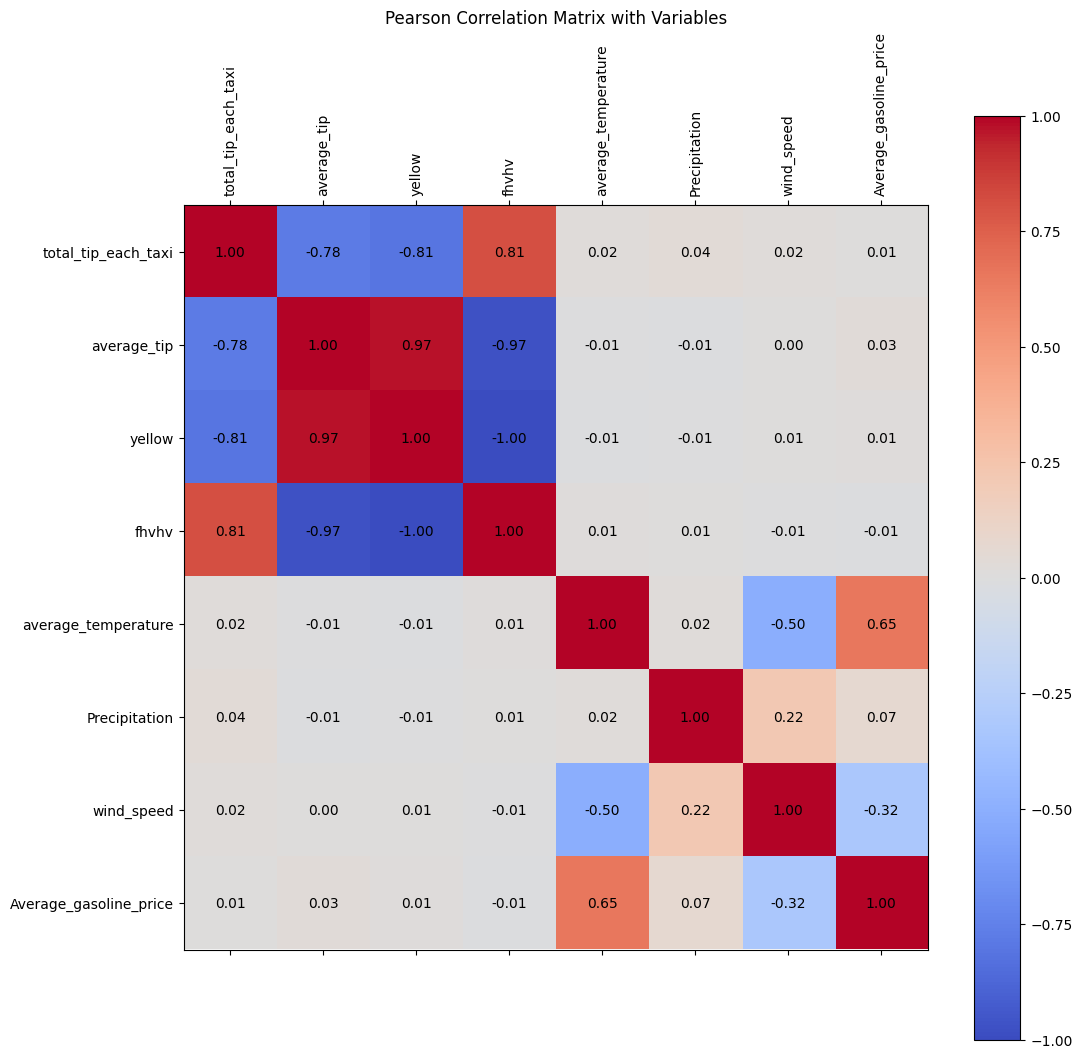

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert to Pandas DataFrame
total_pd = total.toPandas()

# Ensure that the specific columns are present and properly typed
total_pd['yellow'] = total_pd['yellow'].astype(int)
total_pd['fhvhv'] = total_pd['fhvhv'].astype(int)

# Convert 'Average gasoline price' from string to numeric, assuming it contains numerical data
total_pd['Average_gasoline_price'] = pd.to_numeric(total_pd['Average_gasoline_price'], errors='coerce')
total_pd['average_temperature'] = pd.to_numeric(total_pd['average_temperature'], errors='coerce')
total_pd['Precipitation'] = pd.to_numeric(total_pd['Precipitation'], errors='coerce')
total_pd['wind_speed'] = pd.to_numeric(total_pd['wind_speed'], errors='coerce')

# Select numeric columns including the specific columns
numeric_columns = total_pd[list(total_pd.select_dtypes(include=['float64', 'int64']).columns)]

# Drop rows with any missing values (optional)
numeric_columns = numeric_columns.dropna()

# Calculate the correlation matrix
corr_matrix = numeric_columns.corr()

# Set up the matplotlib figure size to handle all variables
fig, ax = plt.subplots(figsize=(len(corr_matrix.columns) * 1.5, len(corr_matrix.columns) * 1.5))

# Create the heatmap
cax = ax.matshow(corr_matrix, cmap='coolwarm')

# Add color bar
fig.colorbar(cax)

# Set ticks and labels
ticks = np.arange(0, len(corr_matrix.columns), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr_matrix.columns, rotation=90, ha="center")
ax.set_yticklabels(corr_matrix.columns)

# Annotate the heatmap with correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

# Set title
plt.title('Pearson Correlation Matrix with Variables')

# Show the plot
plt.show()


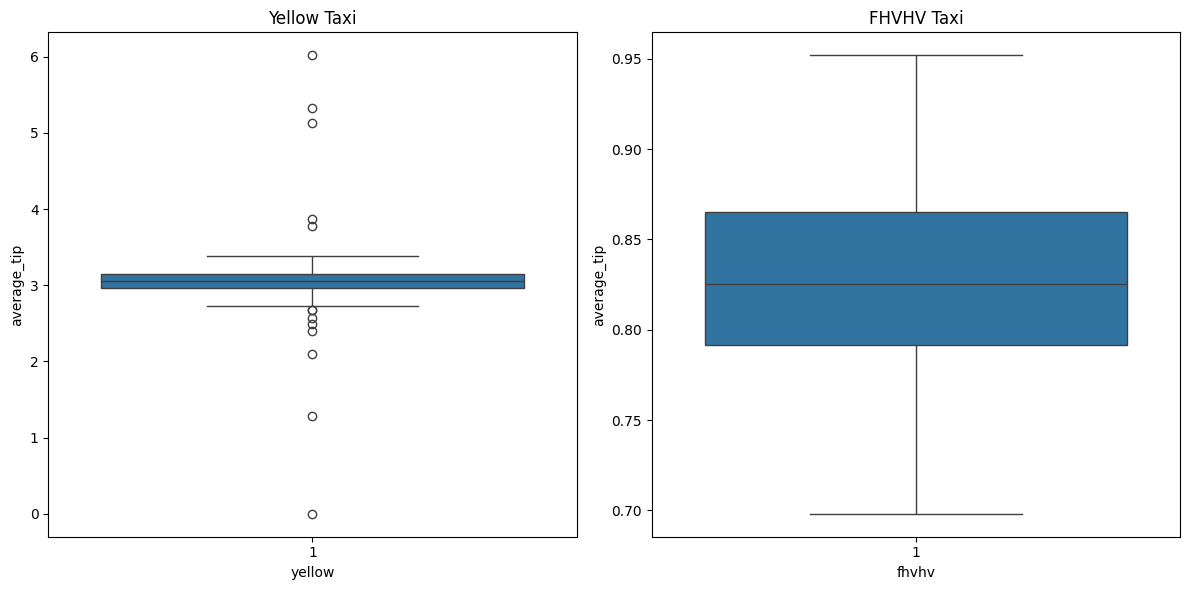

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12,6))


plt.subplot(1,2, 1)
sns.boxplot(x='yellow', y='average_tip', data=total_pd.query('yellow == 1'))
plt.title('Yellow Taxi')



plt.subplot(1,2,2)
sns.boxplot(x='fhvhv', y='average_tip', data=total_pd.query('fhvhv == 1'))
plt.title('FHVHV Taxi')


plt.tight_layout()
plt.show()

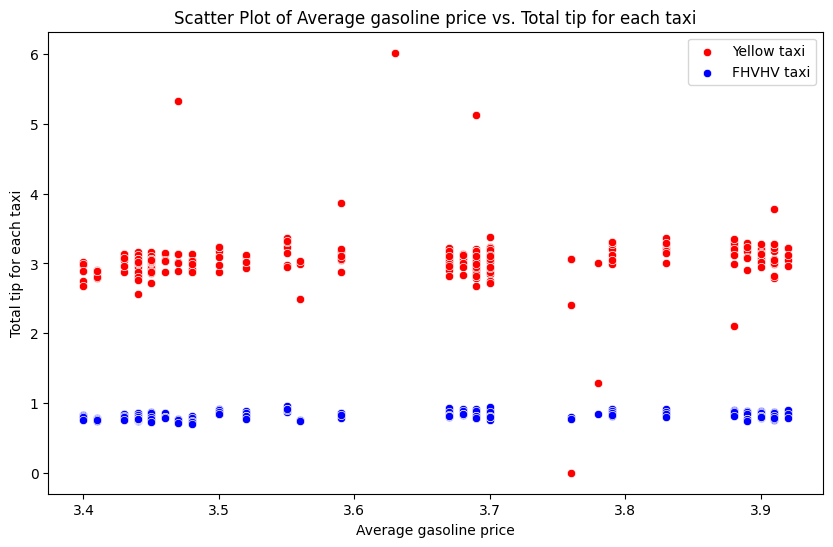

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Average_gasoline_price', y='average_tip', data=total_pd.query('yellow == 1'), color = 'red' , label = 'Yellow taxi')
sns.scatterplot(x='Average_gasoline_price', y='average_tip', data=total_pd.query('fhvhv == 1'), color = 'blue' , label = 'FHVHV taxi')
plt.title('Scatter Plot of Average gasoline price vs. Total tip for each taxi')
plt.xlabel('Average gasoline price')
plt.ylabel('Total tip for each taxi')
plt.show()

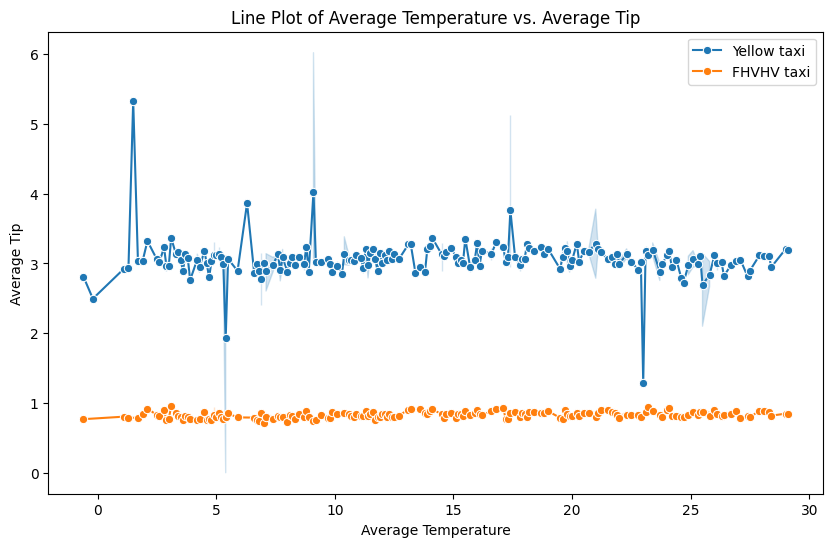

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


sns.lineplot(x='average_temperature', y='average_tip', data=total_pd.query('yellow == 1'), marker='o', label='Yellow taxi')
sns.lineplot(x='average_temperature', y='average_tip', data=total_pd.query('fhvhv == 1'), marker='o', label='FHVHV taxi')


plt.title('Line Plot of Average Temperature vs. Average Tip')
plt.xlabel('Average Temperature')
plt.ylabel('Average Tip')

plt.legend()


plt.show()

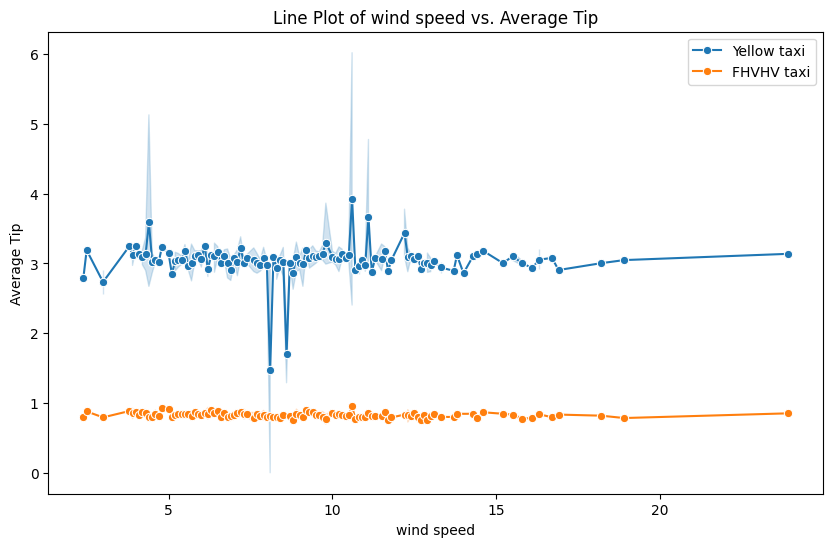

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


sns.lineplot(x='wind_speed', y='average_tip', data=total_pd.query('yellow == 1'), marker='o', label='Yellow taxi')
sns.lineplot(x='wind_speed', y='average_tip', data=total_pd.query('fhvhv == 1'), marker='o', label='FHVHV taxi')


plt.title('Line Plot of wind speed vs. Average Tip')
plt.xlabel('wind speed')
plt.ylabel('Average Tip')

plt.legend()


plt.show()

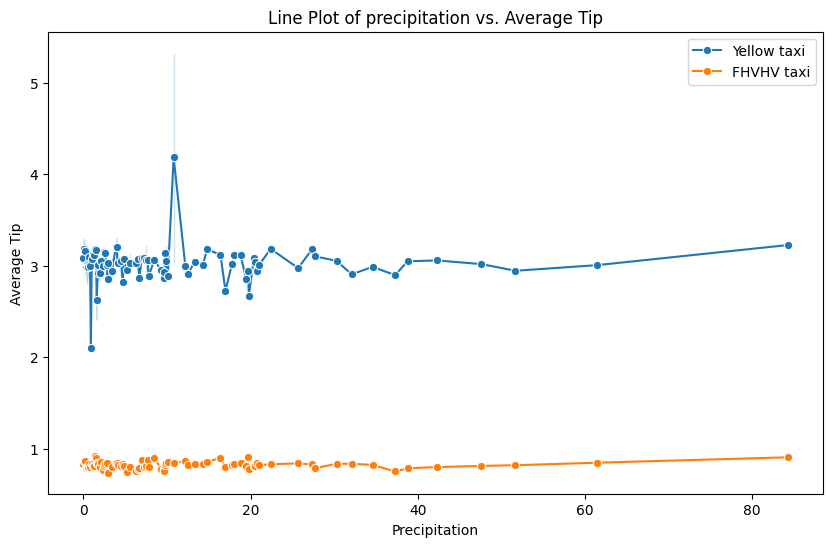

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


sns.lineplot(x='Precipitation', y='average_tip', data=total_pd.query('yellow == 1'), marker='o', label='Yellow taxi')
sns.lineplot(x='Precipitation', y='average_tip', data=total_pd.query('fhvhv == 1'), marker='o', label='FHVHV taxi')


plt.title('Line Plot of precipitation vs. Average Tip')
plt.xlabel('Precipitation')
plt.ylabel('Average Tip')

plt.legend()


plt.show()

In [35]:

from statsmodels.formula.api import ols
# make a ols model
fit_ols = ols(
    formula='average_tip ~ yellow + fhvhv + average_temperature + Precipitation + wind_speed + Average_gasoline_price',
    data=total_pd
).fit()

print(fit_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            average_tip   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     1608.
Date:                Sat, 24 Aug 2024   Prob (F-statistic):          3.30e-304
Time:                        20:41:11   Log-Likelihood:                -69.255
No. Observations:                 503   AIC:                             150.5
Df Residuals:                     497   BIC:                             175.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

In [36]:
from statsmodels.formula.api import  glm
import statsmodels.api as sm

fit_glm_gaussian = glm(
    formula='average_tip ~ yellow + fhvhv + average_temperature + Precipitation + wind_speed + Average_gasoline_price',
    data=total_pd,
    family=sm.families.Gaussian()  
).fit()

AIC = fit_glm_gaussian.aic
BIC = fit_glm_gaussian.bic

print(fit_glm_gaussian.summary())
print(f"AIC: {AIC}")
print(f"BIC: {BIC}")



                 Generalized Linear Model Regression Results                  
Dep. Variable:            average_tip   No. Observations:                  503
Model:                            GLM   Df Residuals:                      497
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                        0.078042
Method:                          IRLS   Log-Likelihood:                -69.255
Date:                Sat, 24 Aug 2024   Deviance:                       38.787
Time:                        20:41:11   Pearson chi2:                     38.8
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/home/ubuntu24/myenv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [37]:
from statsmodels.formula.api import  glm
import statsmodels.api as sm

fit_glm_poisson = glm(
    formula='average_tip ~ yellow + fhvhv + average_temperature + Precipitation + wind_speed + Average_gasoline_price',
    data=total_pd,
    family=sm.families.Poisson()  
).fit()

AIC = fit_glm_gaussian.aic
BIC = fit_glm_gaussian.bic

print(fit_glm_poisson.summary())
print(f"AIC: {AIC}")
print(f"BIC: {BIC}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:            average_tip   No. Observations:                  503
Model:                            GLM   Df Residuals:                      497
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -619.85
Date:                Sat, 24 Aug 2024   Deviance:                       15.345
Time:                        20:41:11   Pearson chi2:                     13.0
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4932
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

/home/ubuntu24/myenv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [38]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


# 假设 total_pd 是你的数据框，并且 y 是目标变量，X 是特征变量

# define x and y in the model
x = total_pd[['yellow', 'fhvhv', 'average_temperature', 'Precipitation', 'wind_speed', 'Average_gasoline_price']]
y = total_pd['average_tip']

# Create and fit the LASSO model
lasso = Lasso(alpha=0.1)  
lasso.fit(x, y)

# Get the coefficients
print("Coefficients:", lasso.coef_)
print("Intercept:", lasso.intercept_)



Coefficients: [ 1.83395768 -0.          0.         -0.         -0.          0.        ]
Intercept: 1.0317244897959181


## find AIC and BIC of Lasson model

In [39]:
# find AIC and BIC 
y_pred = lasso.predict(x)

n = len(y)
mse = mean_squared_error(y, y_pred)
ll = -n/2 * np.log(2 * np.pi * mse) - n/2

# Number of parameters
k = len(lasso.coef_)

# Calculate AIC and BIC
aic = 2 * k - 2 * ll
bic = np.log(n) * k - 2 * ll

print("AIC:", aic)
print("BIC:", bic)


AIC: 363.7735724636825
BIC: 389.09711348428095
